<a href="https://colab.research.google.com/github/2003UJAN/Laryngeal-Cancer-Few-Shot-Learning-XAI/blob/main/Laryngeal_Cancer_XAI_DenseNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pytorch_metric_learning

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [2]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 86.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.2-py3-none-any.whl size=38330 sha256=811d4538647b01bd84ef9c6e45aac5f9bea77cffcce0c5a7aecd63275976114f
  Stored in directory: /root/.cache/pip/wheels/b4/68/bb/d10381e86dc0de1c9354bce3d86bffcd247305058c40ce2e55
Successfully built grad-cam


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from pytorch_metric_learning import losses
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
from torchvision.models import densenet121
import zipfile
import os

In [4]:
zip_path = '/content/archive (5).zip'
extract_path = '.'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [5]:
dataset_path = os.path.join(extract_path, 'laryngeal dataset', 'laryngeal dataset')

In [6]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

In [9]:
def load_dataset(root_path, transform):
  return datasets.ImageFolder(root=root_path, transform=transform)

In [10]:
fold1_path = os.path.join(dataset_path, 'FOLD 1')
fold2_path = os.path.join(dataset_path, 'FOLD 2')
fold3_path = os.path.join(dataset_path, 'FOLD 3')

In [11]:
train_data = load_dataset(fold1_path, transform)
val_data = load_dataset(fold2_path, transform)
test_data = load_dataset(fold3_path, transform)

In [12]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [13]:
class DenseNetPrototypicalNetwork(nn.Module):
    def __init__(self, embedding_dim, num_classes):
        super(DenseNetPrototypicalNetwork, self).__init__()
        self.densenet = densenet121(pretrained=True)
        self.densenet.classifier = nn.Linear(self.densenet.classifier.in_features, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        features = self.densenet.features(x)
        features = torch.flatten(features, start_dim=1)
        embeddings = self.densenet.classifier(features)
        logits = self.classifier(embeddings)
        return logits

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [15]:
embedding_dim = 64
num_classes = len(train_data.classes)
model = DenseNetPrototypicalNetwork(embedding_dim, num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)
criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 125MB/s]


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import densenet121

class DenseNetPrototypicalNetwork(nn.Module):
    def __init__(self, embedding_dim, num_classes):
        super(DenseNetPrototypicalNetwork, self).__init__()
        self.densenet = densenet121(pretrained=True)
        # Remove the classifier to use the DenseNet as a feature extractor
        self.densenet.classifier = nn.Identity()
        # Add a new classifier that fits our embedding_dim
        self.fc = nn.Linear(1024, embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        features = self.densenet.features(x)
        # Apply global average pooling to match the expected input size
        features = nn.functional.adaptive_avg_pool2d(features, (1, 1)).view(features.size(0), -1)
        embeddings = self.fc(features)
        logits = self.classifier(embeddings)
        return logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

embedding_dim = 64
num_classes = len(train_data.classes)
model = DenseNetPrototypicalNetwork(embedding_dim, num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)
criterion = nn.CrossEntropyLoss()

def compute_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total

for epoch in range(40):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    train_acc = compute_accuracy(train_loader)
    val_acc = compute_accuracy(val_loader)

    print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}, '
          f'Train Accuracy: {train_acc*100:.2f}%, Val Accuracy: {val_acc*100:.2f}%')

test_acc = compute_accuracy(test_loader)
print(f'Test Accuracy: {test_acc*100:.2f}%')


Epoch 1, Loss: 0.526556521654129, Train Accuracy: 83.41%, Val Accuracy: 72.05%
Epoch 2, Loss: 0.48308250520910534, Train Accuracy: 61.59%, Val Accuracy: 57.50%
Epoch 3, Loss: 0.296979583799839, Train Accuracy: 84.32%, Val Accuracy: 69.32%
Epoch 4, Loss: 0.3011947769139494, Train Accuracy: 93.86%, Val Accuracy: 80.68%
Epoch 5, Loss: 0.23981184831687383, Train Accuracy: 96.59%, Val Accuracy: 80.00%
Epoch 6, Loss: 0.12934053902115142, Train Accuracy: 89.32%, Val Accuracy: 77.73%
Epoch 7, Loss: 0.1965947068695511, Train Accuracy: 91.36%, Val Accuracy: 74.32%
Epoch 8, Loss: 0.15736241372568266, Train Accuracy: 94.32%, Val Accuracy: 84.55%
Epoch 9, Loss: 0.2519133496763451, Train Accuracy: 87.73%, Val Accuracy: 75.91%
Epoch 10, Loss: 0.1749423760920763, Train Accuracy: 75.23%, Val Accuracy: 66.82%
Epoch 11, Loss: 0.06566801946610212, Train Accuracy: 98.41%, Val Accuracy: 87.27%
Epoch 12, Loss: 0.05311582022945264, Train Accuracy: 99.77%, Val Accuracy: 89.55%
Epoch 13, Loss: 0.018751311814412

In [18]:
def generate_gradcam(model, image, target_layer):
    model.eval()
    if image.shape[0] != model.densenet.features[0].weight.shape[1]:
        image = image.repeat(model.densenet.features[0].weight.shape[1], 1, 1)
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image.unsqueeze(0))[0, :]
    image = image.permute(1, 2, 0).cpu().numpy()
    cam_image = show_cam_on_image(image, grayscale_cam, use_rgb=True)
    return cam_image

In [19]:
test_iter = iter(test_loader)
images, labels = next(test_iter)
image = images[0].to(device)
target_layer = model.densenet.features[-1]
cam_image = generate_gradcam(model, image, target_layer)

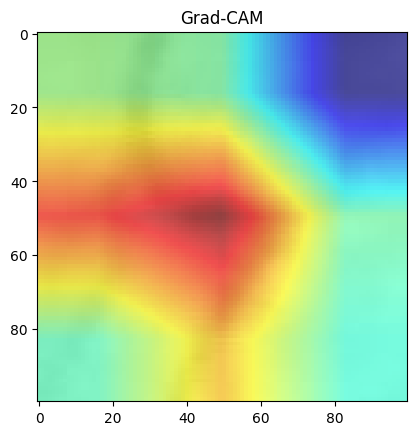

In [20]:
plt.imshow(cam_image)
plt.title('Grad-CAM')
plt.show()